In [12]:
import torch 
from torch import nn 
from torch.utils.data import Dataset , DataLoader 
from torchvision import datasets , models 
from torchvision.transforms import v2 

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device.type} device")

Using cuda device


In [4]:
torch.manual_seed(42); torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = False ; torch.backends.cudnn.bechmarks = True 

# Preparing and loading the Data

In [40]:
transform_train = v2.Compose([
    v2.Resize(224),
    v2.RandomCrop(224,padding=4),
    v2.RandomHorizontalFlip(p = 0.5),
    v2.ToTensor(),
    v2.Normalize(
         mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

transform_test = v2.Compose([
    v2.Resize(224),
    v2.ToTensor(),
    v2.Normalize(
         mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_data = datasets.CIFAR10(
    root = "data",
    train = True , 
    download=True, 
    transform= transform_train
)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download= True,
    transform = transform_test
)

In [41]:
train_data.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [64]:
batch_size = 256 
train_loader = DataLoader(train_data , batch_size = batch_size , shuffle = True)
test_loader  = DataLoader(test_data , batch_size = batch_size , shuffle = False)

In [65]:
X_train , y_train = next(iter(train_loader))
X_test , y_test = next(iter(test_loader))
print(f"X_train shape : {X_train.shape} y_train shape : {y_train.shape}")
print(f"X_test shape : {X_test.shape} y_test shape : {y_train.shape}")

X_train shape : torch.Size([256, 3, 224, 224]) y_train shape : torch.Size([256])
X_test shape : torch.Size([256, 3, 224, 224]) y_test shape : torch.Size([256])


# Calling model and Architecture 

In [66]:
model = models.resnet18(pretrained = True)
NUM_CLASSES = 10 
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(512, NUM_CLASSES)
)

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [67]:
model.fc

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)

In [68]:
x = torch.randn(4, 3, 224, 224)
y = model(x)
y.shape

torch.Size([4, 10])

In [69]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [70]:
# Model summary
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, 32, 32),
    col_names=["input_size", "output_size", "num_params"],
    verbose=1,
);

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet                                   [1, 3, 32, 32]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 3, 32, 32]            [1, 64, 16, 16]           (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 16, 16]           [1, 64, 16, 16]           (128)
├─ReLU: 1-3                              [1, 64, 16, 16]           [1, 64, 16, 16]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           [1, 64, 8, 8]             --
├─Sequential: 1-5                        [1, 64, 8, 8]             [1, 64, 8, 8]             --
│    └─BasicBlock: 2-1                   [1, 64, 8, 8]             [1, 64, 8, 8]             --
│    │    └─Conv2d: 3-1                  [1, 64, 8, 8]             [1, 64, 8, 8]             (36,864)
│    │    └─BatchNorm2d: 3-2             [1, 64, 8, 8]             [1, 64, 8, 8]             (128)
│    │    └─ReLU: 

In [71]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        #  Forward pass
        preds = model(X)
        loss = loss_fn(preds, y)

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

        #  Backward pass
        loss.backward()

        #  Update parameters
        optimizer.step()

        if batch % 100 == 0:
            loss_val = loss.item()
            current = batch * len(X)
            print(f"loss: {loss_val:.6f} [{current}/{size}]")

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

In [72]:
def test(dataloader, model, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.eval()

    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # Forward pass
            preds = model(X)
            loss = loss_fn(preds, y)

            # Accumulate loss & accuracy
            test_loss += loss.item()
            correct += (preds.argmax(1) == y).sum().item()

    avg_loss = test_loss / num_batches
    accuracy = correct / size

    print(
        f"Test Error:\n"
        f" Accuracy: {(100 * accuracy):.1f}%\n"
        f" Avg loss: {test_loss:.6f}\n")
    return avg_loss, accuracy

In [73]:
lr = 0.01
epochs = 10
model = model.to(device)
optimizer = torch.optim.Adam(model.fc.parameters(),lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=5,gamma=0.1)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

In [76]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
best_acc = 0
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    tr_loss, tr_acc = train(train_loader, model, loss_fn, optimizer, device)
    te_loss, te_acc = test(test_loader, model, loss_fn, device)

    train_losses.append(tr_loss)
    train_accuracies.append(tr_acc)
    test_losses.append(te_loss)
    test_accuracies.append(te_acc)
    scheduler.step()
    
    if te_acc > best_acc:
        best_acc = te_acc  
        torch.save(model.state_dict(), "tune_Resnet.pth")
print("Done!")

Epoch 1
-------------------------------
loss: 1.340673 [0/50000]
loss: 1.238595 [25600/50000]
Test Error:
 Accuracy: 77.9%
 Avg loss: 42.895221

Epoch 2
-------------------------------
loss: 1.318892 [0/50000]
loss: 1.219376 [25600/50000]
Test Error:
 Accuracy: 78.2%
 Avg loss: 42.725915

Epoch 3
-------------------------------
loss: 1.209374 [0/50000]
loss: 1.258905 [25600/50000]
Test Error:
 Accuracy: 78.2%
 Avg loss: 42.665900

Epoch 4
-------------------------------
loss: 1.235375 [0/50000]
loss: 1.218616 [25600/50000]
Test Error:
 Accuracy: 78.2%
 Avg loss: 42.709555

Epoch 5
-------------------------------
loss: 1.259185 [0/50000]
loss: 1.270474 [25600/50000]


KeyboardInterrupt: 

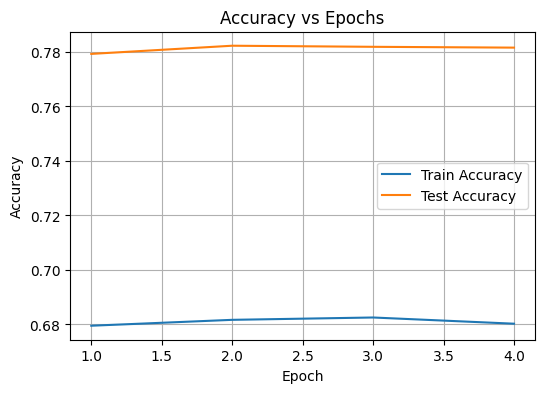

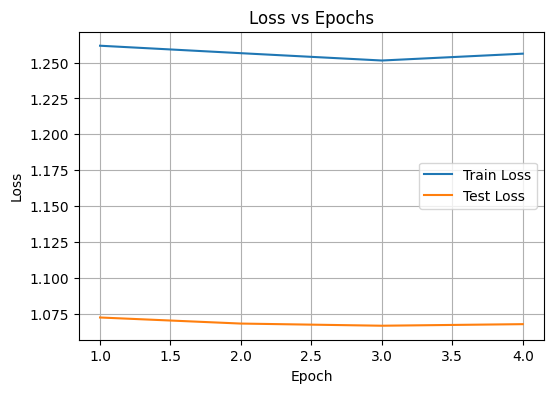

In [77]:
from matplotlib  import pyplot as plt 
epochs_range = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
num_modules = len(list(model.modules()))
print("Total modules:", num_modules)

Total modules: 70


In [62]:
total_params = 0
trainable_params = 0

for p in model.parameters():
    total_params += p.numel()
    if p.requires_grad:
        trainable_params += p.numel()

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Frozen params: {total_params - trainable_params:,}")


Total params: 11,181,642
Trainable params: 5,130
Frozen params: 11,176,512


In [63]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)


fc.1.weight
fc.1.bias


In [ ]:
# optimizer = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, model.parameters()),
#     lr=1e-3
# )